              precision    recall  f1-score   support

     On-time       0.66      0.86      0.75     16307
        Late       0.85      0.63      0.72     19797

    accuracy                           0.73     36104
   macro avg       0.75      0.75      0.73     36104
weighted avg       0.76      0.73      0.73     36104



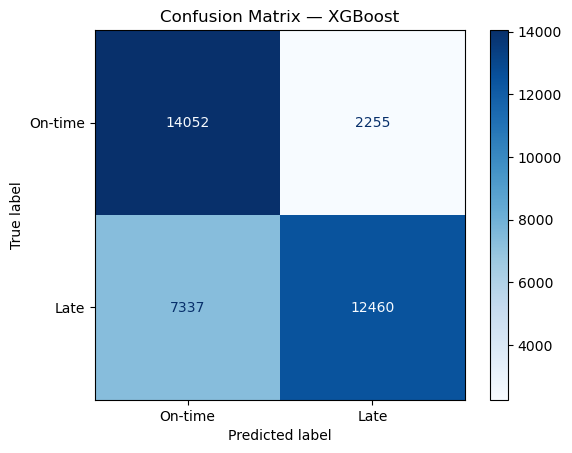

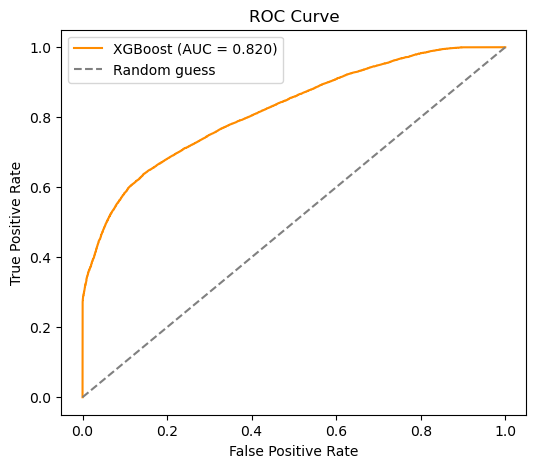

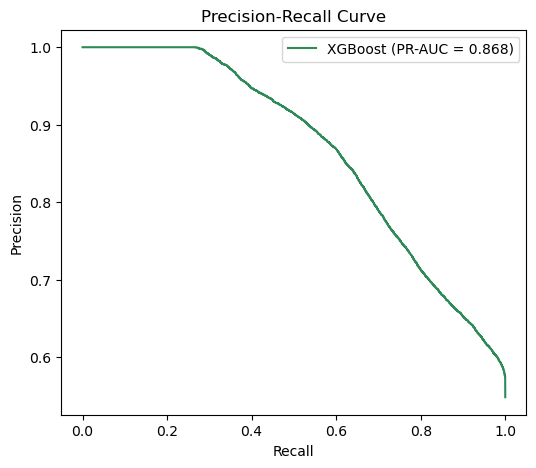

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)

# Load model + processed test data
model = joblib.load('../artifacts/xgb_model.pkl')

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 1. Classification report
print(classification_report(y_test, y_pred, target_names=['On-time', 'Late']))

# 2. Confusion matrix (visual)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-time', 'Late'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — XGBoost')
plt.show()

# 3. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 4. Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'XGBoost (PR-AUC = {pr_auc:.3f})', color='seagreen')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [ ]:

sample = X_test.sample(5, random_state=42)
sample_proba = model.predict_proba(sample)[:, 1]
sample_pred = model.predict(sample)

for idx, (proba, pred) in zip(sample.index, zip(sample_proba, sample_pred)):
    actual = y_test.loc[idx]
    print(f"Row {idx}: Delay Probability = {proba*100:.1f}% | "
          f"Predicted = {'Late' if pred==1 else 'On-time'} | "
          f"Actual = {'Late' if actual==1 else 'On-time'}")

Row 19705: Delay Probability = 60.4% | Predicted = Late | Actual = On-time
Row 25153: Delay Probability = 81.3% | Predicted = Late | Actual = Late
Row 9641: Delay Probability = 100.0% | Predicted = Late | Actual = Late
Row 26410: Delay Probability = 32.6% | Predicted = On-time | Actual = On-time
Row 5875: Delay Probability = 79.2% | Predicted = Late | Actual = Late
